In [1]:
using LinearAlgebra
using QuantumToolbox
using CairoMakie

In [5]:
const devisions = 64
const count_iterations = 1024

initial_state = ComplexF64[1;0]
T_gate = ComplexF64[1 0; 0 exp(im*π/(devisions/2))]
rot_90 = ComplexF64[1/√2 -1/√2; 1/√2 1/√2]

function measure(vec)
    if abs2(vec[1]) > rand()
        vec[1] = 1
        vec[2] = 0
        return 0
        end
    vec[1] = 0
    vec[2] = 1
    return 1
end

function ramsey(t)
    return measure(rot_90 * T_gate ^ t * rot_90 * initial_state)
end

function count(n, t)
    count = 0
    for i in range(1,n)
        measured = ramsey(t)
        if measured == 1
            count += 1
        end
    end
    return count
end

function operate(time, Δf)
    iter = time * devisions * Δf
    t_range = range(1, iter)
    data = []
    probs = []
    conv = []
    for i in t_range
        counted = count(count_iterations, i)
        push!(data, counted)
        push!(probs, counted/count_iterations)
        push!(conv, (i * 1/Δf)/devisions)
    end

    return [data, probs, conv]
end

operate (generic function with 1 method)

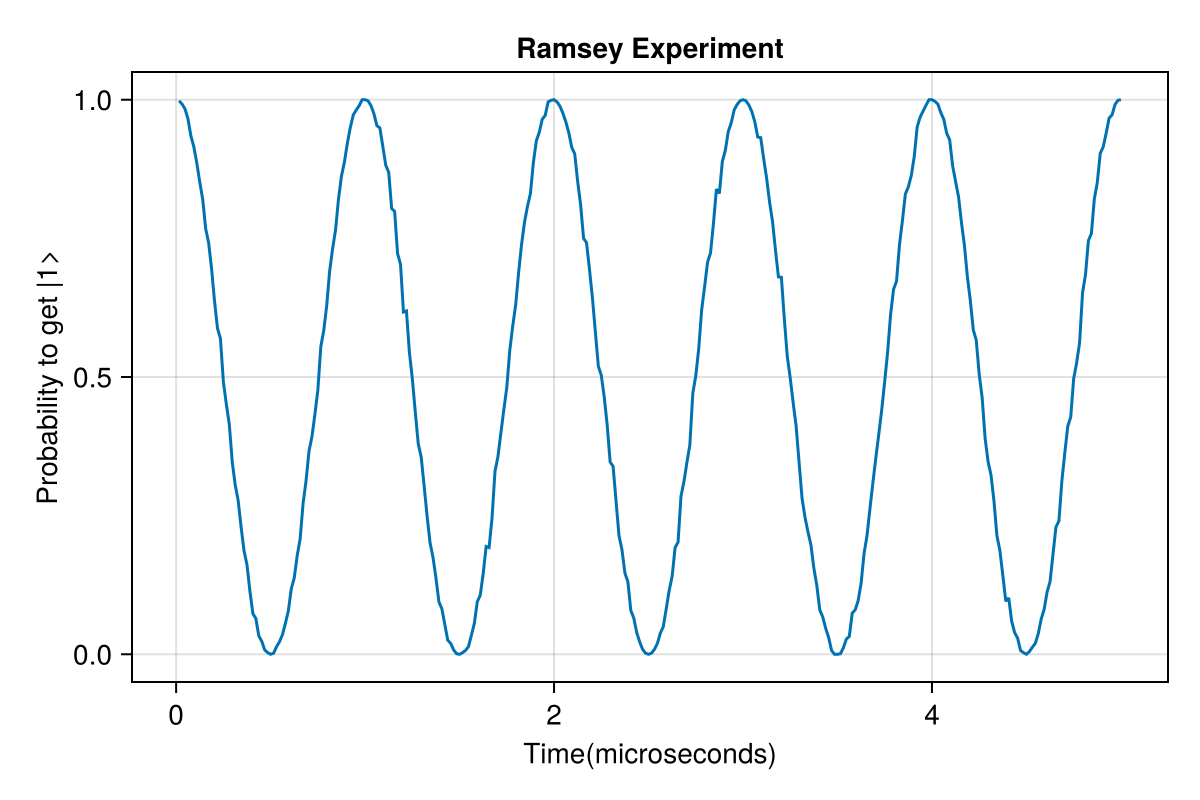

CairoMakie.Screen{IMAGE}


In [ ]:
g = operate(5,1)
fig = Figure(size = (600, 400))
ax = Axis(fig[1, 1], title = "Ramsey Experiment", xlabel = "Time(microseconds)", ylabel = "Probability to get |1>")
lines!(ax, g[3], g[2])
display(fig)

In [7]:
function generate_time(time, Δf)
    iter = time * devisions * Δf
    t_range = range(1, iter)
    conv = []
    for i in t_range
        push!(conv, (i * 1/Δf)/devisions)
    end
    return conv
end

function generate_time_2(time, Δf)
    iter = time * devisions
    t_range = range(1, iter)
    conv = []
    for i in t_range
        push!(conv, (i * 1/Δf)/devisions)
    end
    return conv
end

generate_time_2 (generic function with 1 method)

In [8]:
generate_time(10,1)

640-element Vector{Any}:
  0.015625
  0.03125
  0.046875
  0.0625
  0.078125
  0.09375
  0.109375
  0.125
  0.140625
  0.15625
  ⋮
  9.875
  9.890625
  9.90625
  9.921875
  9.9375
  9.953125
  9.96875
  9.984375
 10.0

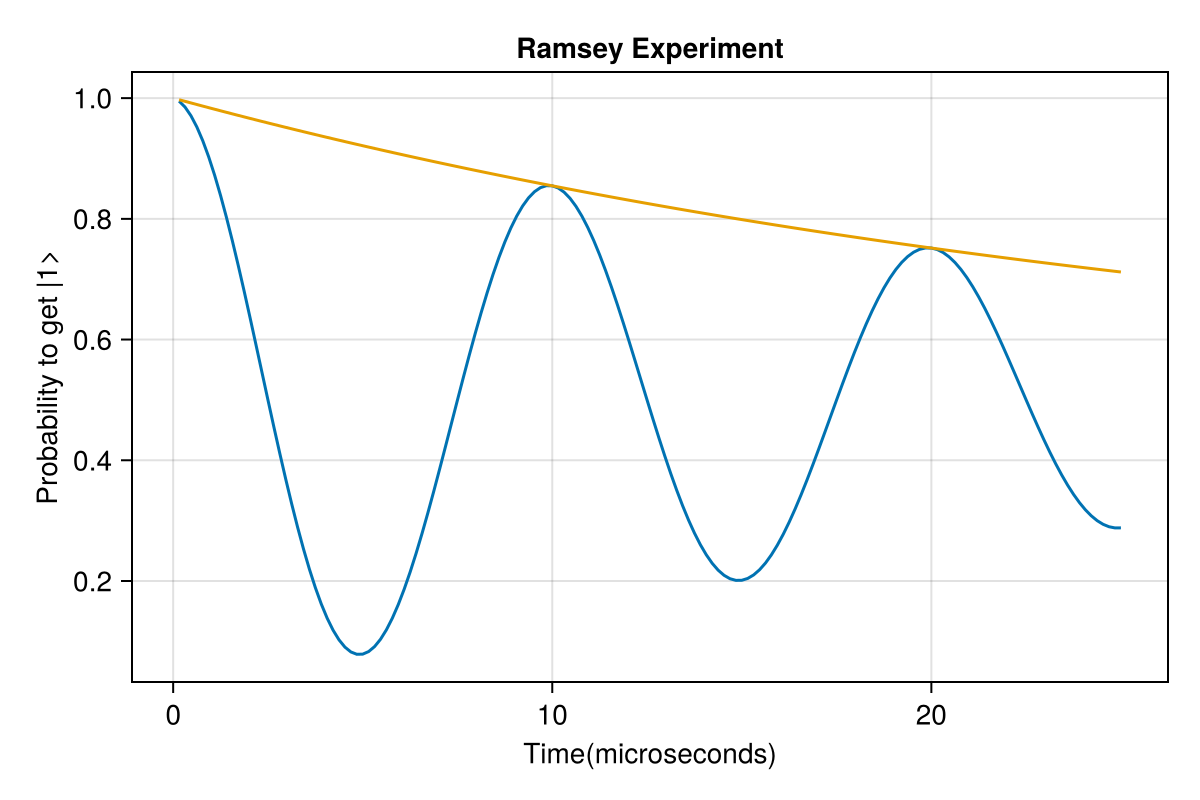

Time to precess(microseconds): 10.0


In [9]:
T1 = 15 * 1000 #Microseconds(1000x nanoseconds)
Tϕ = 10^3 * 1000 #Microseconds(1000x nanoseconds)
T2x = (1/2T1 + 1/Tϕ)^-1/1000
function Probability_Ramsey(time,Δ)
    Ts = generate_time(time, Δ)   
    function P(t)
        return 0.5 * exp(-t/T2x) * cos(2π * Δ * t) + 0.5
    end

    function border(t)
         return 0.5 * exp(-t/T2x) + 0.5
    end

    decaying = []
    bord= []
    for i in Ts
        push!(decaying, P(i))
        push!(bord, border(i))
    end

    return Ts, decaying, bord
end

Δf = 0.1#MHz
t = 25
Decay = Probability_Ramsey(t, Δf)
fig = Figure(size = (600, 400))
ax = Axis(fig[1, 1], title = "Ramsey Experiment", xlabel = "Time(microseconds)", ylabel = "Probability to get |1>")
lines!(ax, Decay[1], Decay[2])
lines!(ax, Decay[1], Decay[3])
display(fig)

println("Time to precess(microseconds): ", 1/Δf)

In [ ]:
Δ = 1
h = 6.626 #* 10**-34
ħ = h/(2*π)
Ω0 = 2π * 0.1
rot_90 = ComplexF64[1/√2 -1/√2; 1/√2 1/√2]
σx = ComplexF64[0 1; 1 0]
σy = ComplexF64[0 -im; im  0]
σz = ComplexF64[1 0; 0 -1]


H = ħ/2 * Δ * σz

2×2 Matrix{ComplexF64}:
 0.52728+0.0im       0.0+0.0im
     0.0+0.0im  -0.52728+0.0im